In [214]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,SimpleRNN,Dropout

In [215]:
text = '''Twinkle, twinkle, little star,
How I wonder what you are!
Up above the world so high,
Like a diamond in the sky.
When the blazing sun is gone,
When he nothing shines upon,
Then you show your little light,
Twinkle, twinkle, all the night.
Then the traveler in the dark
Thanks you for your tiny spark,
How could he see where to go,
If you did not twinkle so?
In the dark blue sky you keep,
Often through my curtains peep
For you never shut your eye,
Till the sun is in the sky.
As your bright and tiny spark
Lights the traveler in the dark,
Though I know not what you are,
Twinkle, twinkle, little star.
'''

In [216]:
text = text.lower()

print("تعداد تمام کاراکترها :",len(text))
print("تعداد کاراکترهای یونیک :",len(set(text)))

char_list = sorted(list(set(text)))
print(char_list)

تعداد تمام کاراکترها : 602
تعداد کاراکترهای یونیک : 29
['\n', ' ', '!', ',', '.', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z']


In [217]:
char_to_idx = {}
for i in range(len(char_list)):
    char_to_idx[char_list[i]] = i
print(char_to_idx)

idx_to_char = {}
for k,v in char_to_idx.items():
    idx_to_char[v] = k
print(idx_to_char)

{'\n': 0, ' ': 1, '!': 2, ',': 3, '.': 4, '?': 5, 'a': 6, 'b': 7, 'c': 8, 'd': 9, 'e': 10, 'f': 11, 'g': 12, 'h': 13, 'i': 14, 'k': 15, 'l': 16, 'm': 17, 'n': 18, 'o': 19, 'p': 20, 'r': 21, 's': 22, 't': 23, 'u': 24, 'v': 25, 'w': 26, 'y': 27, 'z': 28}
{0: '\n', 1: ' ', 2: '!', 3: ',', 4: '.', 5: '?', 6: 'a', 7: 'b', 8: 'c', 9: 'd', 10: 'e', 11: 'f', 12: 'g', 13: 'h', 14: 'i', 15: 'k', 16: 'l', 17: 'm', 18: 'n', 19: 'o', 20: 'p', 21: 'r', 22: 's', 23: 't', 24: 'u', 25: 'v', 26: 'w', 27: 'y', 28: 'z'}


In [218]:
word = "hello"

# رمزنگاری کردن داده
word_ramzi = []
for i in word:
    word_ramzi.append(char_to_idx[i])
print(word_ramzi)

# شکستن رمز داده
word_asli = []
for i in word_ramzi:
    word_asli.append(idx_to_char[i])
print("".join(word_asli))

[13, 10, 16, 16, 19]
hello


In [219]:
window_size = 3
x = []
y = []

for i in range(len(text)-window_size):
    seq = text[i : i+window_size]
    label = text[i+window_size]
    x.append(seq)
    y.append(label)
print(x)
print(y)

['twi', 'win', 'ink', 'nkl', 'kle', 'le,', 'e, ', ', t', ' tw', 'twi', 'win', 'ink', 'nkl', 'kle', 'le,', 'e, ', ', l', ' li', 'lit', 'itt', 'ttl', 'tle', 'le ', 'e s', ' st', 'sta', 'tar', 'ar,', 'r,\n', ',\nh', '\nho', 'how', 'ow ', 'w i', ' i ', 'i w', ' wo', 'won', 'ond', 'nde', 'der', 'er ', 'r w', ' wh', 'wha', 'hat', 'at ', 't y', ' yo', 'you', 'ou ', 'u a', ' ar', 'are', 're!', 'e!\n', '!\nu', '\nup', 'up ', 'p a', ' ab', 'abo', 'bov', 'ove', 've ', 'e t', ' th', 'the', 'he ', 'e w', ' wo', 'wor', 'orl', 'rld', 'ld ', 'd s', ' so', 'so ', 'o h', ' hi', 'hig', 'igh', 'gh,', 'h,\n', ',\nl', '\nli', 'lik', 'ike', 'ke ', 'e a', ' a ', 'a d', ' di', 'dia', 'iam', 'amo', 'mon', 'ond', 'nd ', 'd i', ' in', 'in ', 'n t', ' th', 'the', 'he ', 'e s', ' sk', 'sky', 'ky.', 'y.\n', '.\nw', '\nwh', 'whe', 'hen', 'en ', 'n t', ' th', 'the', 'he ', 'e b', ' bl', 'bla', 'laz', 'azi', 'zin', 'ing', 'ng ', 'g s', ' su', 'sun', 'un ', 'n i', ' is', 'is ', 's g', ' go', 'gon', 'one', 'ne,', 'e,\n',

In [220]:
x_seq = []
for item in x:
    item_idx = []
    for char in item:
        item_idx.append(char_to_idx[char])
    x_seq.append(item_idx)
print(x_seq)

y_seq = []
for i in y:
    y_seq.append(char_to_idx[i])
print(y_seq)

[[23, 26, 14], [26, 14, 18], [14, 18, 15], [18, 15, 16], [15, 16, 10], [16, 10, 3], [10, 3, 1], [3, 1, 23], [1, 23, 26], [23, 26, 14], [26, 14, 18], [14, 18, 15], [18, 15, 16], [15, 16, 10], [16, 10, 3], [10, 3, 1], [3, 1, 16], [1, 16, 14], [16, 14, 23], [14, 23, 23], [23, 23, 16], [23, 16, 10], [16, 10, 1], [10, 1, 22], [1, 22, 23], [22, 23, 6], [23, 6, 21], [6, 21, 3], [21, 3, 0], [3, 0, 13], [0, 13, 19], [13, 19, 26], [19, 26, 1], [26, 1, 14], [1, 14, 1], [14, 1, 26], [1, 26, 19], [26, 19, 18], [19, 18, 9], [18, 9, 10], [9, 10, 21], [10, 21, 1], [21, 1, 26], [1, 26, 13], [26, 13, 6], [13, 6, 23], [6, 23, 1], [23, 1, 27], [1, 27, 19], [27, 19, 24], [19, 24, 1], [24, 1, 6], [1, 6, 21], [6, 21, 10], [21, 10, 2], [10, 2, 0], [2, 0, 24], [0, 24, 20], [24, 20, 1], [20, 1, 6], [1, 6, 7], [6, 7, 19], [7, 19, 25], [19, 25, 10], [25, 10, 1], [10, 1, 23], [1, 23, 13], [23, 13, 10], [13, 10, 1], [10, 1, 26], [1, 26, 19], [26, 19, 21], [19, 21, 16], [21, 16, 9], [16, 9, 1], [9, 1, 22], [1, 22, 1

In [221]:
x_seq = np.array(x_seq)
y_seq = np.array(y_seq)

x_seq.shape , y_seq.shape

((599, 3), (599,))

In [222]:
x_seq[0].shape

(3,)

In [223]:
model = Sequential()
model.add(Embedding(input_dim=29,
                    output_dim=50,
                    input_shape=(3,)))

model.add(SimpleRNN(50,activation="relu",return_sequences=True))
model.add(SimpleRNN(50,activation="relu"))

model.add(Dense(50,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(29,activation="softmax"))
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 3, 50)          │         1,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_18 (SimpleRNN)       │ (None, 3, 50)          │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_19 (SimpleRNN)       │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 29)             │         1,479 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,579 (60.86 KB)

 Trainable params: 15,579 (60.86 KB)

 Non-trainable params: 0 (0.00 B)

In [224]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [225]:
hist = model.fit(x_seq, y_seq, epochs=100)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0885 - loss: 3.3409       
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1436 - loss: 3.1863 
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1536 - loss: 2.9817 
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2187 - loss: 2.8275 
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2487 - loss: 2.6841 
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2738 - loss: 2.5643 
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3372 - loss: 2.4513 
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3239 - loss: 2.3831 
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3639 - loss: 2.2683 
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3873 - loss: 2.1864 
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4190 - loss: 2.1014 
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

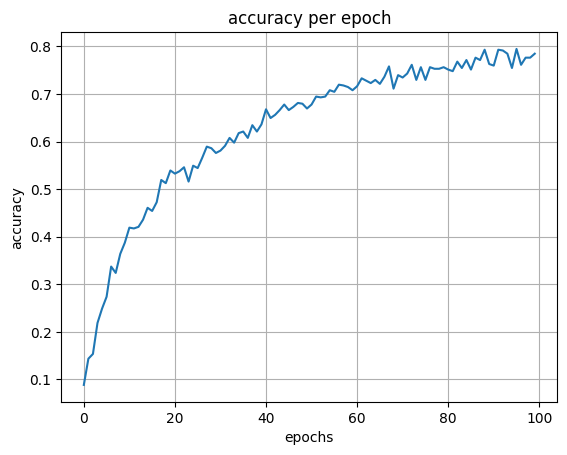

In [227]:
plt.plot(hist.history["accuracy"])
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("accuracy per epoch")
plt.grid()
plt.show()

In [ ]:
# تشخیص یک کاراکتر بعدی
word = "lit"
word_index = []
for i in word:
    word_index.append(char_to_idx[i])

word_index = np.array([word_index])

y_idx = np.argmax(model.predict(word_index))
y_char = idx_to_char[y_idx]
print(word+y_char)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
litt


In [244]:
# تشخیص چند کاراکتر بعدی
word = "twi"

for c in range(10):
    word_index = []
    for i in word[-3:]:
        word_index.append(char_to_idx[i])
    word_index = np.array([word_index])
    y_idx = np.argmax(model.predict(word_index))
    y_char = idx_to_char[y_idx]
    word += y_char
    
print(word)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
twinkle, twin
